# LFP alpha model

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
import importlib
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import single_neuron_utils as sn

2025-08-21 11:57:52.510334: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-21 11:57:52.524794: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-21 11:57:52.538921: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-21 11:57:52.542758: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-21 11:57:52.554904: I tensorflow/core/platform/cpu_feature_guar

## one alpha model

In [4]:
# TRAINED WITH 30K TRIALS AND 1.5*OUTPUT + LFP LOSS, BL 10-50 -- TARGET ALPHA 9-12
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
model_fname = 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_19_124334.mat'
# mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

In [5]:
model_name = model_fname[:-4]
model_dir = os.path.join(all_models_dir, model_name)
delay=50

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
data_files

['/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_19_124334/neuraldata_raw_delay50.mat',
 '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_19_124334/timingdata_raw_delay50.mat',
 '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_19_124334/bhvdata_raw_delay50.mat']

In [6]:
# neural data
lfp_data, spk_times_df, rates_data = ld.load_neural_data(model_name, condn_phrase=f'delay{delay}',
                                                  load_LFP=True, load_spikes=True, load_rates=True,
                                                  all_models_dir = all_models_dir)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay,
                                             all_models_dir=all_models_dir)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay,
                                             all_models_dir=all_models_dir)
times_ms, _,_ = ld.get_times_dict('ds', 'delay', 50, model_name,
                                  all_models_dir=all_models_dir)

In [8]:
print(f'Average performance for delay {delay}: {trial_perfs.mean()}')

Average performance for delay 50: 1.0


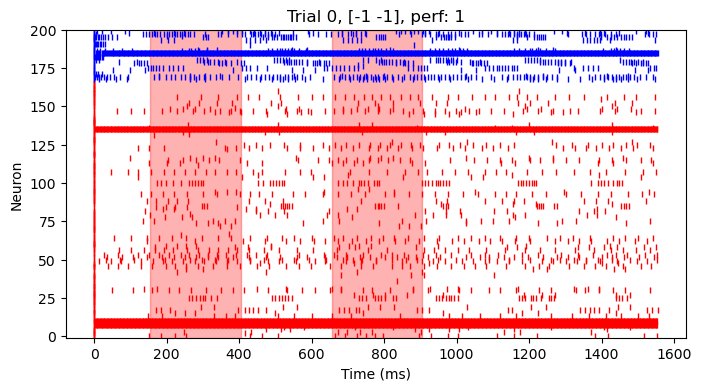

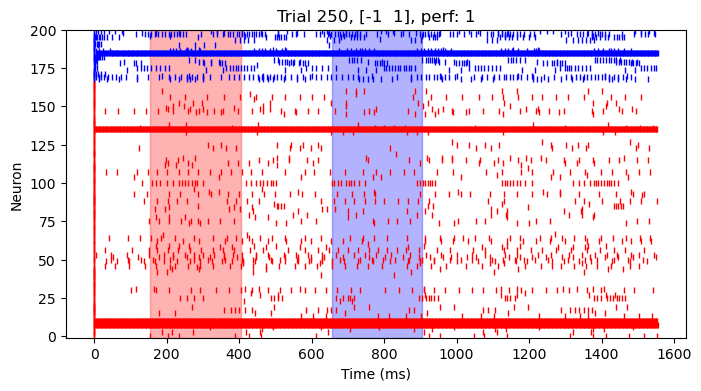

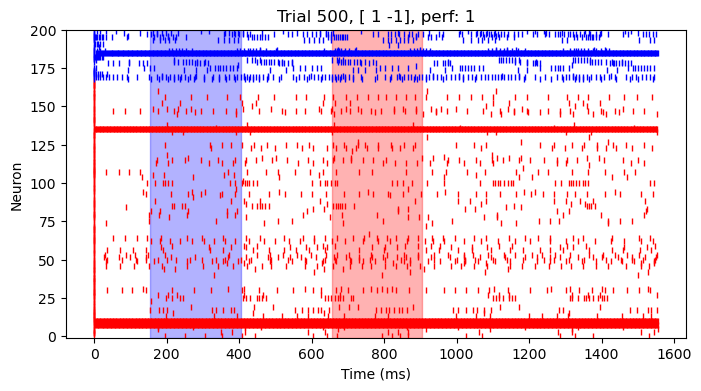

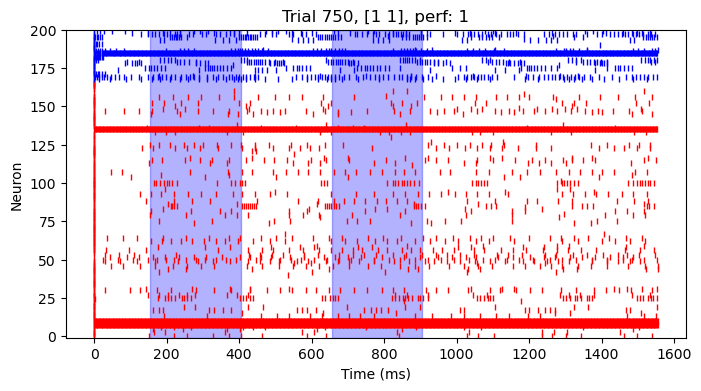

In [9]:
for trial_id in [0, 250, 500, 750]:
    trial_df = spk_times_df[spk_times_df['trial_id'] == trial_id]
    sn.plot_trial_raster(trial_df, 'delay', 50, all_models_dir=all_models_dir,)

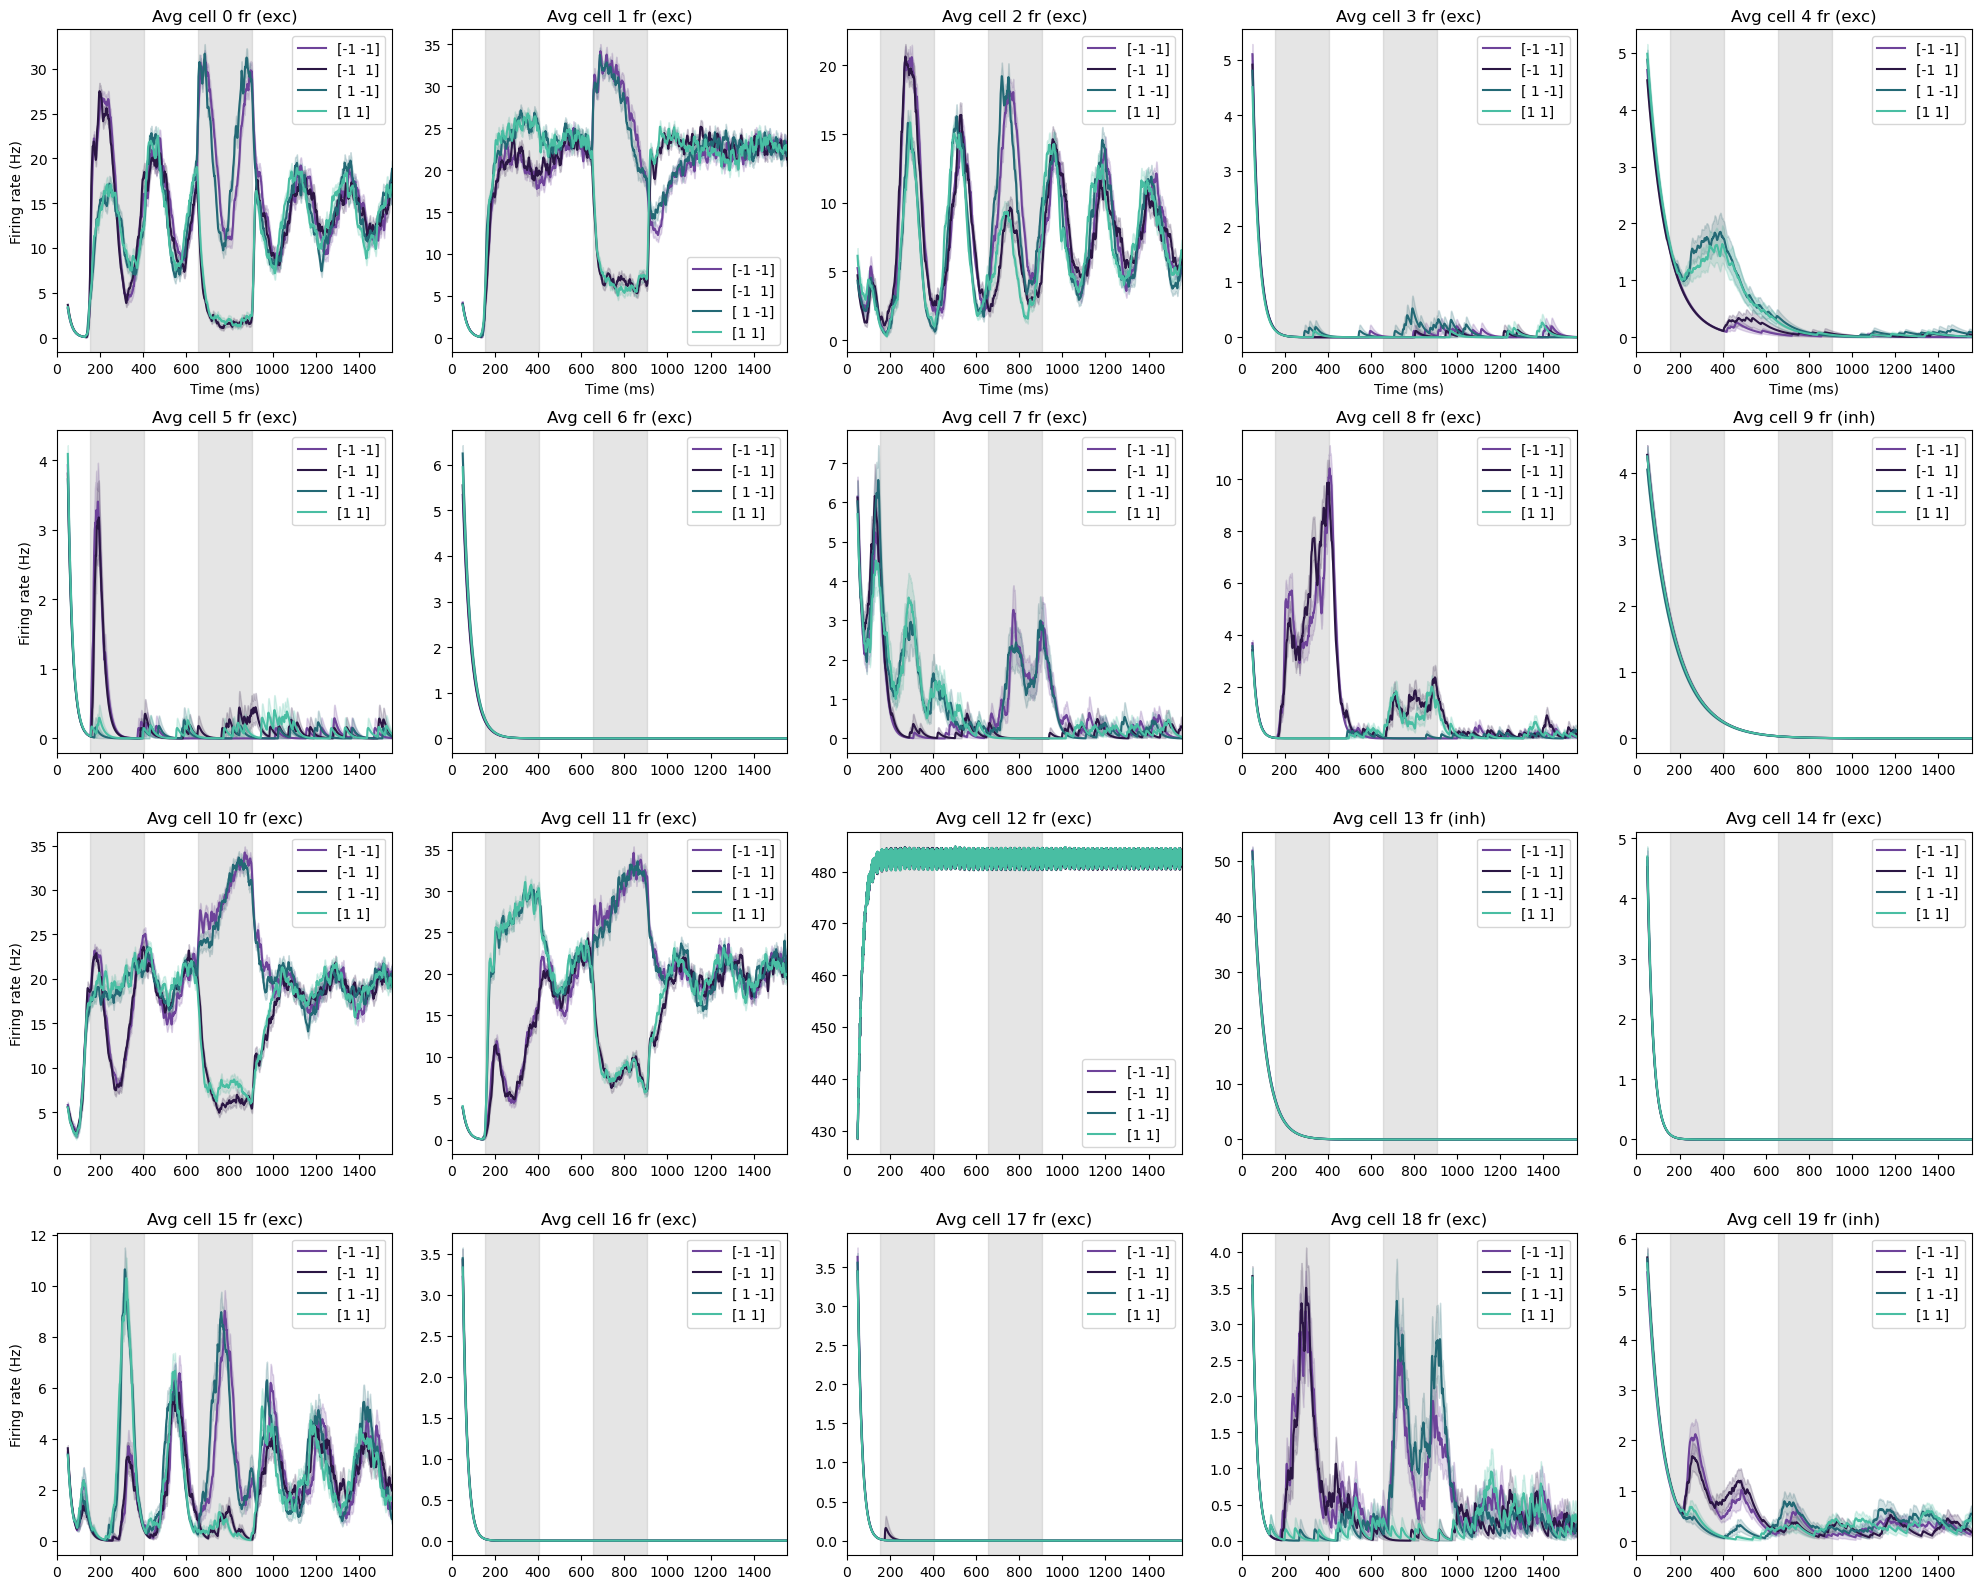

In [10]:
# let's take a look some neurons
importlib.reload(sn)

fig, axs = plt.subplots(4,5, figsize=(20,16))
axs = axs.flatten()
for n_neuron in range(20):
    sn.plot_neuron_rates(model_name, n_neuron, 'delay', 50, rates_data = rates_data, 
                         cut_off=50, baseline=False, ax=axs[n_neuron],
                         all_models_dir=all_models_dir)
    # axs[n_neuron].set_title(f'Neuron {n_neuron}')

# remove axis labels besides the first row and first column
for i in range(4):
    for j in range(5):
        if i > 0:
            axs[i*5 + j].set_xlabel('')
        if j > 0:
            axs[i*5 + j].set_ylabel('')
        
plt.tight_layout()
plt.show()


In [18]:
lfp_data.shape

(1555, 200, 1000)

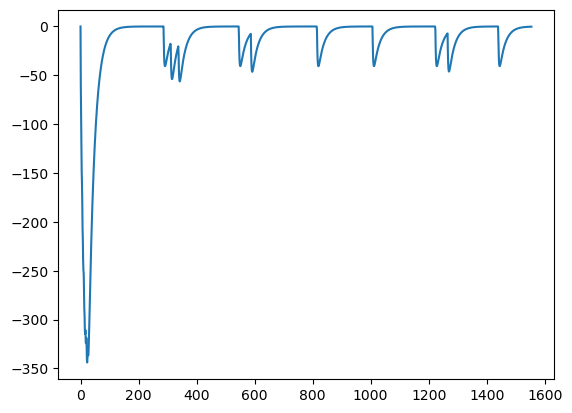

In [11]:
plt.plot(lfp_data[:,0,0])

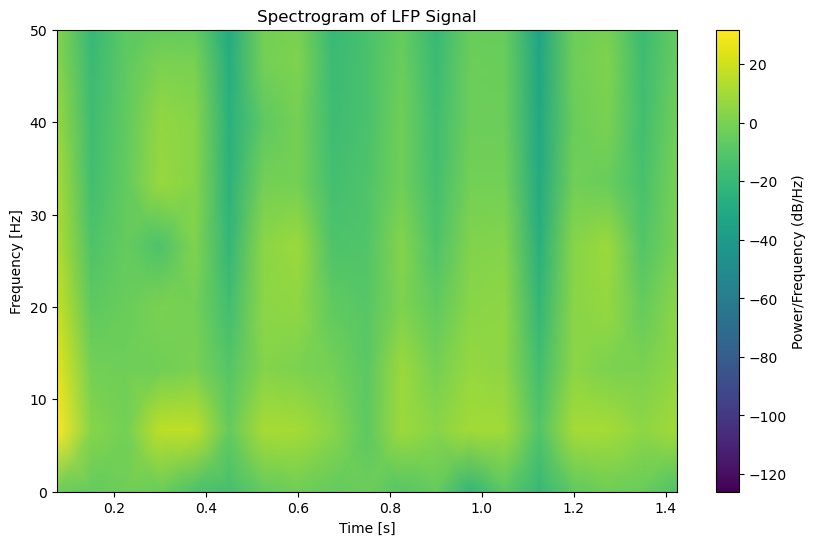

In [12]:
from scipy.signal import spectrogram

f, t, s = spectrogram(lfp_data[:,0,0], fs=1000, window=('tukey', 0.25),
                          nperseg=150, noverlap=75, nfft=150, scaling='density') 

# plot
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, 10 * np.log10(s), shading='gouraud', cmap='viridis')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectrogram of LFP Signal')
plt.ylim(0, 50)  # Limit frequency axis to 50 Hz
plt.show()

In [13]:
# get exc lfp data

exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
lfp_exc = lfp_data[:, exc_ind, :].mean(axis=1)
lfp_inh = lfp_data[:, inh_ind, :].mean(axis=1)

print(lfp_exc.shape, lfp_inh.shape)

(1555, 1000) (1555, 1000)


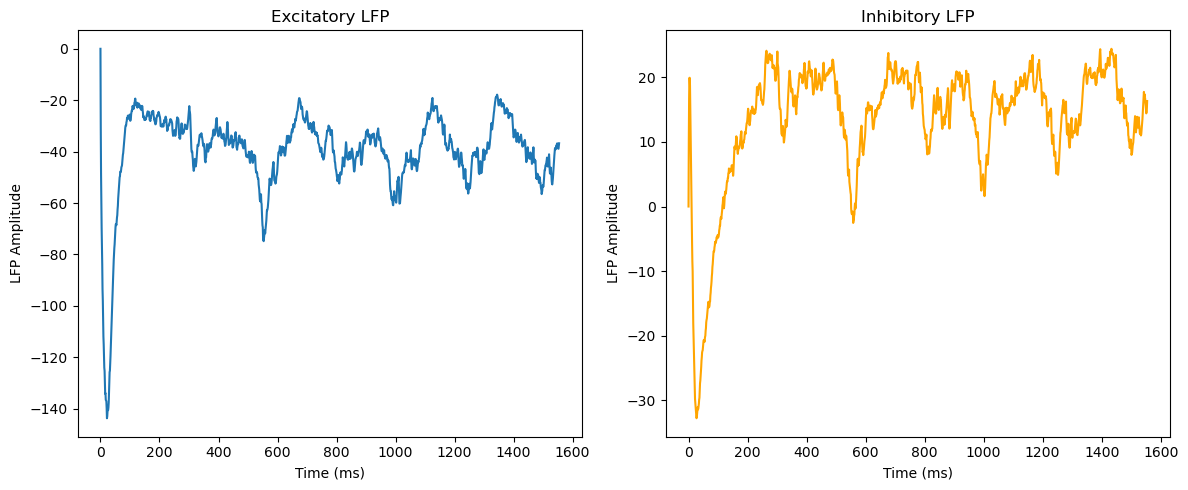

In [14]:
fig, axs = plt.subplots(1,2, figsize=(12,5))
axs[0].plot(lfp_exc[:,0])
axs[0].set_title('Excitatory LFP')
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('LFP Amplitude')
axs[1].plot(lfp_inh[:,0], color='orange')
axs[1].set_title('Inhibitory LFP')
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('LFP Amplitude')
plt.tight_layout()
plt.show()

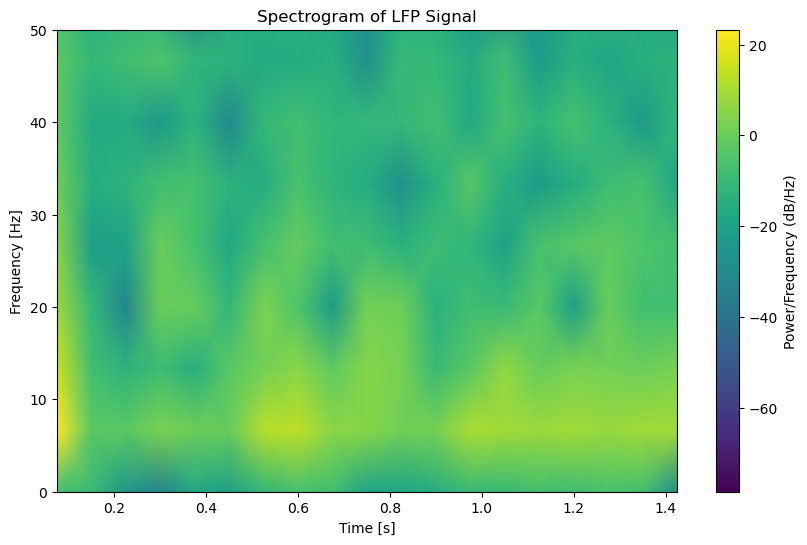

In [15]:
from scipy.signal import spectrogram

f, t, s = spectrogram(lfp_exc[:,0], fs=1000, window=('tukey', 0.25),
                          nperseg=150, noverlap=75, nfft=150, scaling='density') 

# plot
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, 10 * np.log10(s), shading='gouraud', cmap='viridis')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectrogram of LFP Signal')
plt.ylim(0, 50)  # Limit frequency axis to 50 Hz
plt.show()

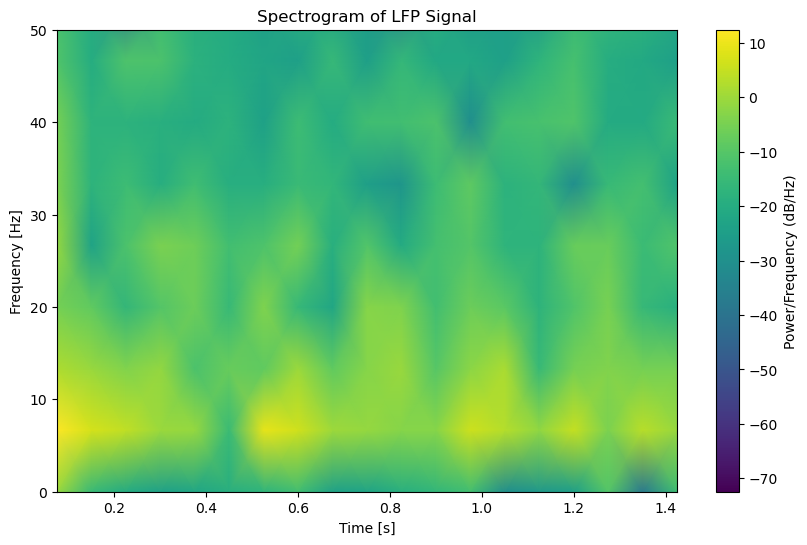

In [16]:
from scipy.signal import spectrogram

f, t, s = spectrogram(lfp_inh[:,0], fs=1000, window=('tukey', 0.25),
                          nperseg=150, noverlap=75, nfft=150, scaling='density') 

# plot
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, 10 * np.log10(s), shading='gouraud', cmap='viridis')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectrogram of LFP Signal')
plt.ylim(0, 50)  # Limit frequency axis to 50 Hz
plt.show()

## A different one

In [17]:
# TRAINED WITH 30K TRIALS AND 1.5*OUTPUT + LFP LOSS, BL 10-50 -- TARGET ALPHA 9-12
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
model_fname = 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_19_162258.mat'
# mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

In [18]:
model_name = model_fname[:-4]
model_dir = os.path.join(all_models_dir, model_name)
delay=50

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
data_files

['/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_19_162258/neuraldata_raw_delay50.mat',
 '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_19_162258/timingdata_raw_delay50.mat',
 '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_19_162258/bhvdata_raw_delay50.mat']

In [19]:
# neural data
lfp_data, spk_times_df, rates_data = ld.load_neural_data(model_name, condn_phrase=f'delay{delay}',
                                                  load_LFP=True, load_spikes=True, load_rates=True,
                                                  all_models_dir = all_models_dir)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay,
                                             all_models_dir=all_models_dir)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay,
                                             all_models_dir=all_models_dir)
times_ms, _,_ = ld.get_times_dict('ds', 'delay', 50, model_name,
                                  all_models_dir=all_models_dir)

In [20]:
print(f'Average performance for delay {delay}: {trial_perfs.mean()}')

Average performance for delay 50: 0.984


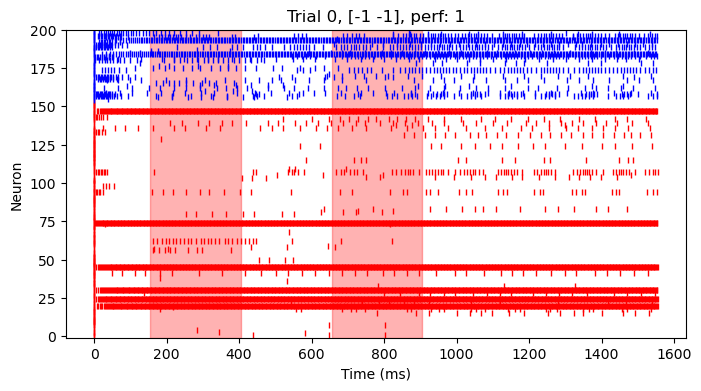

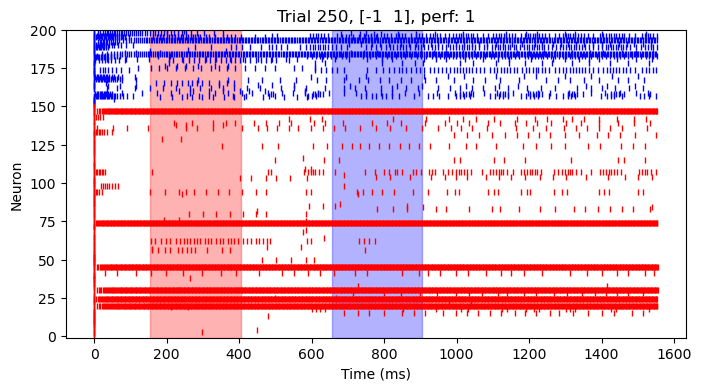

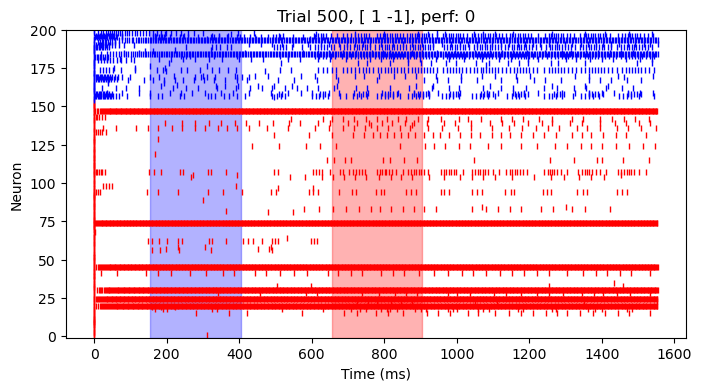

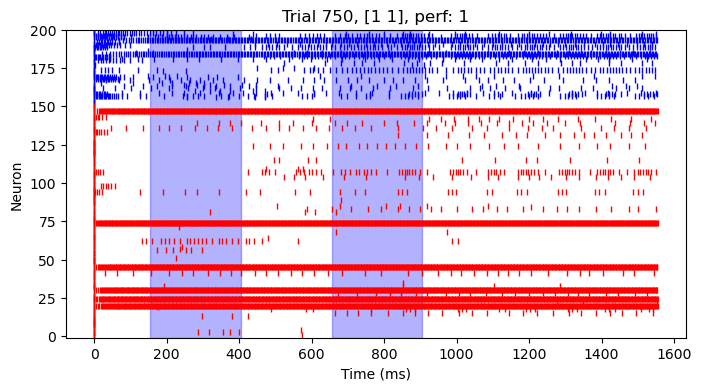

In [21]:
for trial_id in [0, 250, 500, 750]:
    trial_df = spk_times_df[spk_times_df['trial_id'] == trial_id]
    sn.plot_trial_raster(trial_df, 'delay', 50, all_models_dir=all_models_dir,)

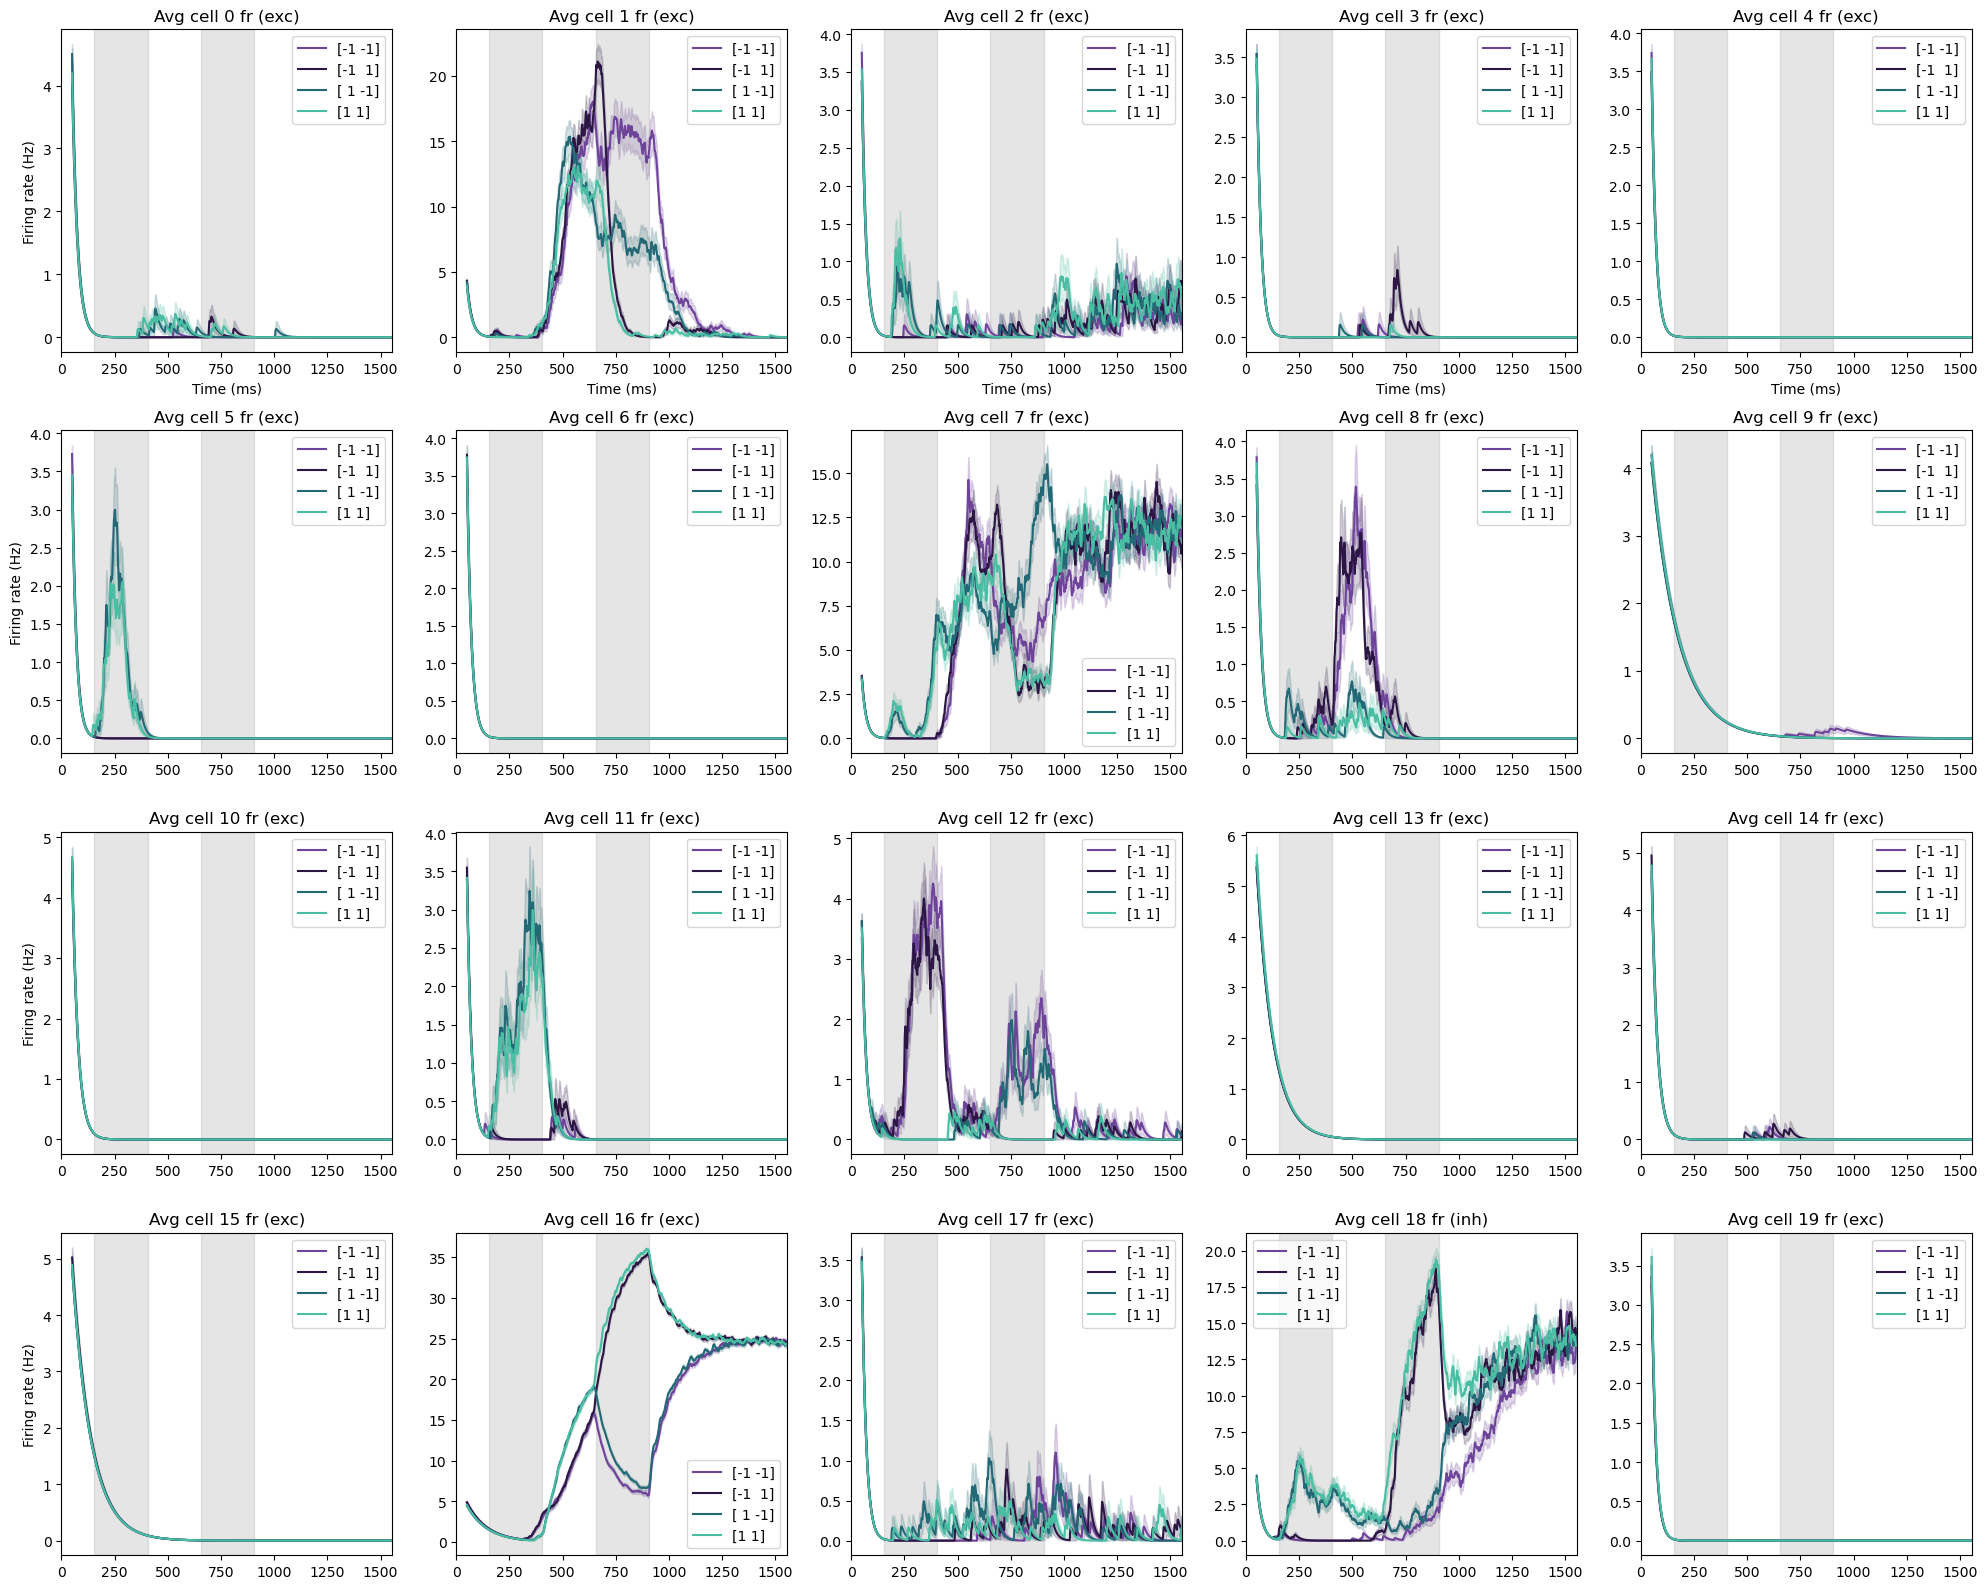

In [22]:
# let's take a look some neurons
importlib.reload(sn)

fig, axs = plt.subplots(4,5, figsize=(20,16))
axs = axs.flatten()
for n_neuron in range(20):
    sn.plot_neuron_rates(model_name, n_neuron, 'delay', 50, rates_data = rates_data, 
                         cut_off=50, baseline=False, ax=axs[n_neuron],
                         all_models_dir=all_models_dir)
    # axs[n_neuron].set_title(f'Neuron {n_neuron}')

# remove axis labels besides the first row and first column
for i in range(4):
    for j in range(5):
        if i > 0:
            axs[i*5 + j].set_xlabel('')
        if j > 0:
            axs[i*5 + j].set_ylabel('')
        
plt.tight_layout()
plt.show()


In [ ]:
lfp_data.shape

(1555, 200, 1000)

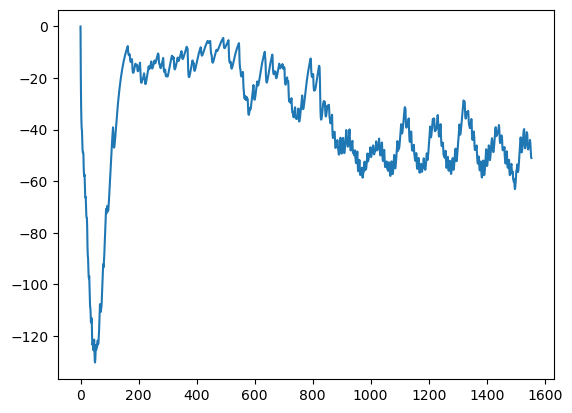

In [23]:
plt.plot(lfp_data[:,0,0])

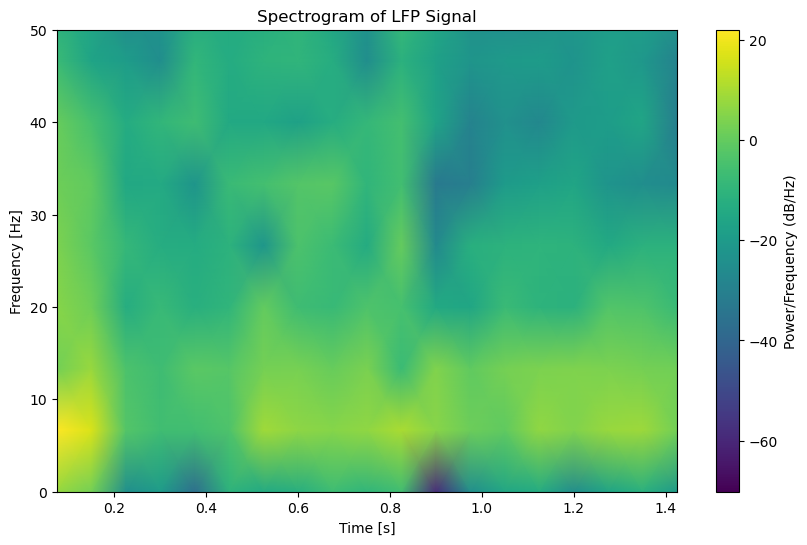

In [24]:
from scipy.signal import spectrogram

f, t, s = spectrogram(lfp_data[:,0,0], fs=1000, window=('tukey', 0.25),
                          nperseg=150, noverlap=75, nfft=150, scaling='density') 

# plot
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, 10 * np.log10(s), shading='gouraud', cmap='viridis')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectrogram of LFP Signal')
plt.ylim(0, 50)  # Limit frequency axis to 50 Hz
plt.show()

In [25]:
# get exc lfp data

exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
lfp_exc = lfp_data[:, exc_ind, :].mean(axis=1)
lfp_inh = lfp_data[:, inh_ind, :].mean(axis=1)

print(lfp_exc.shape, lfp_inh.shape)

(1555, 1000) (1555, 1000)


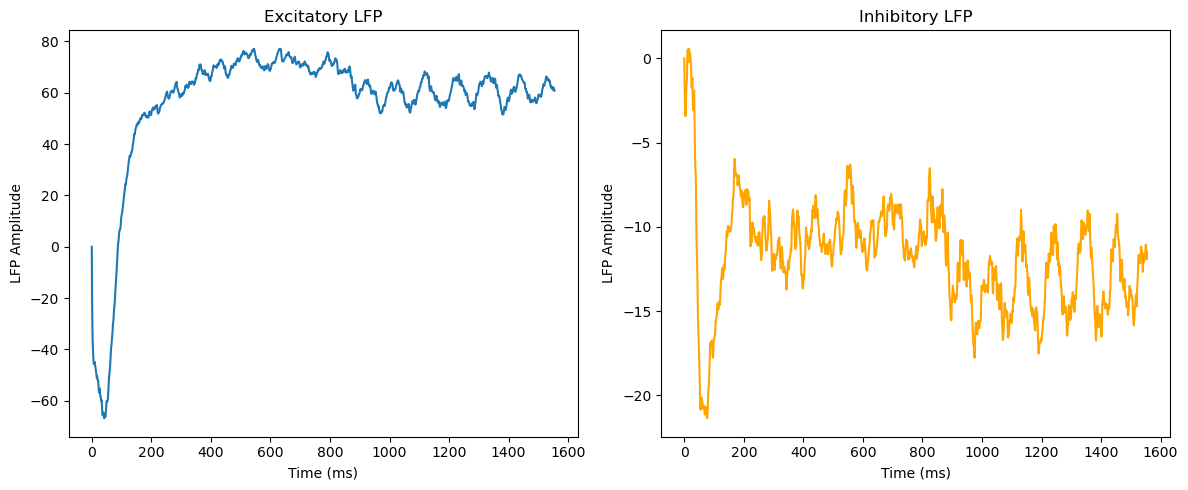

In [26]:
fig, axs = plt.subplots(1,2, figsize=(12,5))
axs[0].plot(lfp_exc[:,0])
axs[0].set_title('Excitatory LFP')
axs[0].set_xlabel('Time (ms)')
axs[0].set_ylabel('LFP Amplitude')
axs[1].plot(lfp_inh[:,0], color='orange')
axs[1].set_title('Inhibitory LFP')
axs[1].set_xlabel('Time (ms)')
axs[1].set_ylabel('LFP Amplitude')
plt.tight_layout()
plt.show()

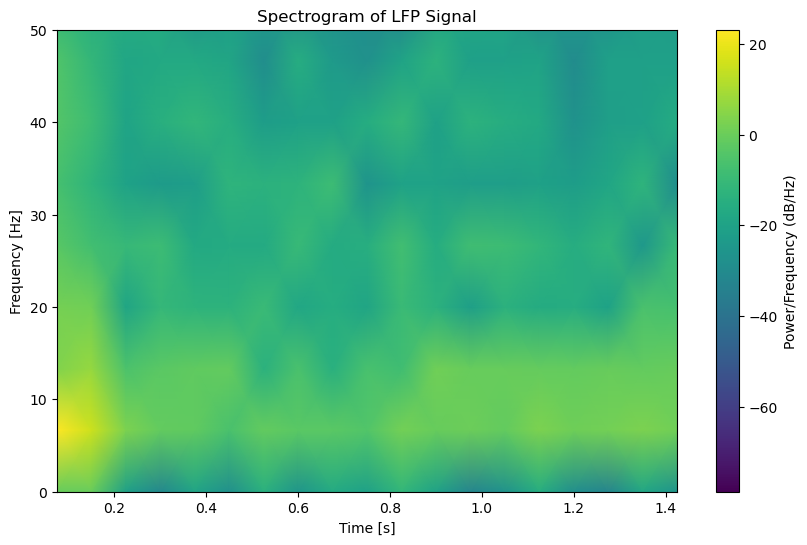

In [27]:
from scipy.signal import spectrogram

f, t, s = spectrogram(lfp_exc[:,0], fs=1000, window=('tukey', 0.25),
                          nperseg=150, noverlap=75, nfft=150, scaling='density') 

# plot
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, 10 * np.log10(s), shading='gouraud', cmap='viridis')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectrogram of LFP Signal')
plt.ylim(0, 50)  # Limit frequency axis to 50 Hz
plt.show()

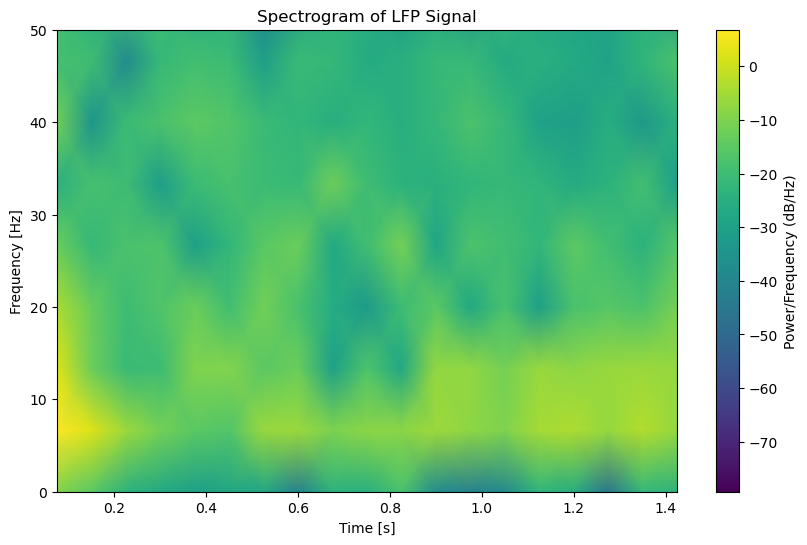

In [28]:
from scipy.signal import spectrogram

f, t, s = spectrogram(lfp_inh[:,0], fs=1000, window=('tukey', 0.25),
                          nperseg=150, noverlap=75, nfft=150, scaling='density') 

# plot
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, 10 * np.log10(s), shading='gouraud', cmap='viridis')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectrogram of LFP Signal')
plt.ylim(0, 50)  # Limit frequency axis to 50 Hz
plt.show()

In [ ]:
from scipy.signal import convolve

def compute_lfp_power(epsp, settings, lfp_power_target=[4,8]):
    # ---- Settings ----
    T         = int(settings['T'])
    fs        = settings['fs']
    dt        = 1.0 / fs
    fmin, fmax = 4.0, 100.0
    num_freqs = 40
    band_lo, band_hi = lfp_power_target # e.g., [30, 80]
    stim_on   = settings['stim1_on']

    # ---- EPSP signal (shape: [T] or [T,1]) ----
    epsp_vec = np.squeeze(epsp)  # shape: (T,)
    assert epsp_vec.shape[0] == T, f"Expected length {T}, got {epsp_vec.shape[0]}"

    # ---- Frequencies & Morlet scales ----
    freqs = np.exp(np.linspace(np.log(fmin), np.log(fmax), num_freqs))  # [F]
    fc = 0.8125
    scales = fc / (freqs * dt)

    # ---- Build Morlet kernels ----
    K = 6.0
    sigma_t_low = K / (2.0 * np.pi * fmin)
    half_width_sec = 4.0 * sigma_t_low
    kernel_len = int(round(2.0 * half_width_sec * fs) + 1)
    kernel_len = max(kernel_len, 31)
    t_idx = np.arange(kernel_len) - (kernel_len - 1) / 2.0
    t_sec = t_idx / fs  # [L]

    two_pi = 2.0 * np.pi
    sigma_t = K / (two_pi * freqs)  # [F]
    env = np.exp(-0.5 * (t_sec[:, None] / sigma_t[None, :]) ** 2)  # [L, F]
    phase = two_pi * t_sec[:, None] * freqs[None, :]              # [L, F]
    cos_part = env * np.cos(phase)
    sin_part = env * np.sin(phase)

    # ---- Normalize kernels ----
    eps = 1e-8
    norm = np.sqrt(np.sum(cos_part**2 + sin_part**2, axis=0, keepdims=True) + eps)  # [1,F]
    cos_part /= norm
    sin_part /= norm

    # ---- Convolve EPSP with wavelets ----
    real_coeff = np.zeros((T, num_freqs))
    imag_coeff = np.zeros((T, num_freqs))
    for f in range(num_freqs):
        real_coeff[:, f] = convolve(epsp_vec, cos_part[:, f], mode='same')
        imag_coeff[:, f] = convolve(epsp_vec, sin_part[:, f], mode='same')

    power = real_coeff**2 + imag_coeff**2  # [T, F]

    # ---- Select and average power in frequency band ----
    band_mask = np.logical_and(freqs >= band_lo, freqs <= band_hi)  # [F]
    band_mask_f = band_mask.astype(np.float32)
    denom = max(np.sum(band_mask_f), 1.0)
    band_power = power @ (band_mask_f / denom)  # [T]

    # ---- Baseline z-score ----
    start = 25
    stop = int(stim_on)
    base_slice = band_power[start:stop]
    base_mean = np.mean(base_slice)
    base_std = np.std(base_slice) + 1e-8
    lfp_power_z = (band_power - base_mean) / base_std  # [T]

    return power, freqs, lfp_power_z


In [ ]:
times_ms

{'stim1_on': 155.0,
 'stim1_off': 405.0,
 'stim2_on': 655.0,
 'stim2_off': 905.0,
 'T': 1555.0,
 'delay': 250.0,
 'stim_dur': 250.0,
 'fs': 1000}

In [ ]:
power, freqs, bandpower_z = compute_lfp_power(lfp_exc[:,0], times_ms, lfp_power_target=[4,8])

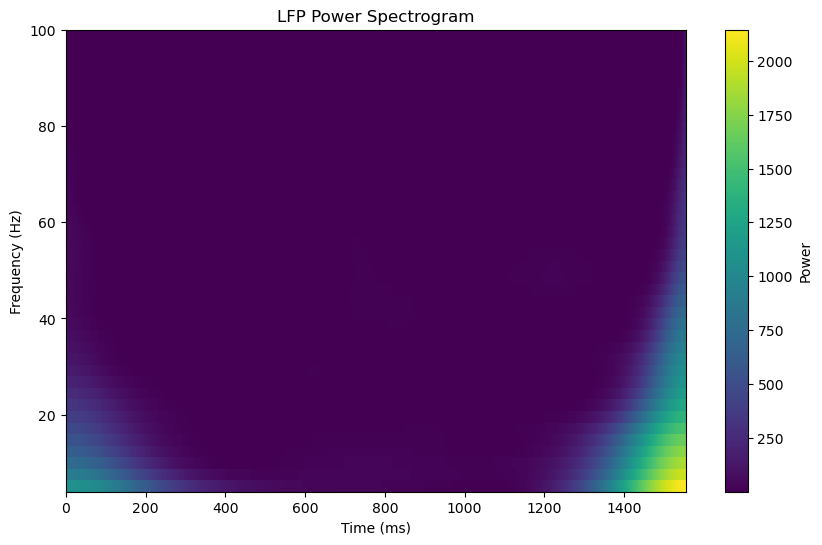

In [ ]:
# plot power

plt.figure(figsize=(10, 6))
plt.imshow(power.T, aspect='auto', origin='lower',
           extent=[0, times_ms['T'], freqs[0], freqs[-1]],
           cmap='viridis', interpolation='none')
plt.colorbar(label='Power')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (ms)')
plt.title('LFP Power Spectrogram')
plt.show()